In [1]:
# General libraries
import numpy as np
from scipy import stats
import os

# Parallelisation libraries
from joblib import Parallel, delayed

# Module functions
import ximinf.selection_effects as se
import ximinf.generate_sim as gsim
import ximinf.nn_io as nnio
import ximinf.nn_inference as nninf
import ximinf.nn_train as nntr
import ximinf.nn_test as nnte
from config import noise_model
from config import params
from config import M
from config import z_max
from config import params as default_params
from config import get_quality_mask

# Plot libraries
import matplotlib.pyplot as plt
import corner
from getdist import MCSamples, plots
%matplotlib inline

from absl import logging
logging.set_verbosity(logging.ERROR)

In [2]:
num_threads = os.cpu_count()
print(f"Number of threads: {num_threads}")

Number of threads: 48


## Load NN

In [3]:
# Parameters
models_per_group, models_config = nnio.load_autoregressive_nn('../data/NNs/nn_model_priors_uniform_M_N_10000_3_M_1000_quality_cuts_batch_100_lr_2e-4_weight_1e-3_prompt_beta_alpha_gamma_M_dropout_0_0_phi_0_05_rho_values_err_deepset_patience_20_128_1024_deep_1_params') #nn_model_priors_M1000_cosmo_err_z_smaller_dropout

for model_g in models_per_group:
    model_g.eval()  # disable dropout, etc.

## Generate test samples

In [4]:
# -------- User parameters --------

N = 1 # Number of samples 100_000

# ---------------------------------

columns = models_config["shared"]["columns"]
priors = models_config["shared"]["priors"]

n_realisation = 200

N_total = N*n_realisation

# print("Repeating fixed parameters...")

param_names = list(params.keys())

# print('Sampling parameters...')
# params_dict = gsim.scan_params(priors, N, n_realisation)
# print("... done")

In [5]:
seed_seq = np.random.SeedSequence(42)
child_seeds = seed_seq.spawn(N_total)


In [6]:
print("Running parallel simulations ...")
# with parallel_backend("threading"):
results = Parallel(n_jobs=min(N_total//20, num_threads-2))(
    delayed(gsim.simulate_one)(
        default_params, #{k: v[i] for k, v in params_dict.items()}, #default_params
        z_max=z_max,
        M=M,
        cols=columns,
        default_params=default_params,
        errormodel=noise_model,
        rng=np.random.default_rng(child_seeds[i]),
        # survey_name='ZTF',
        # c=colour_distrib,
        N=N_total,
        i=i
    )
    for i in range(N_total)
)
print("... done")

Running parallel simulations ...


/pbs/throng/ztf/anaconda3/envs/sbi/lib/python3.11/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


... doneon 200/200


In [7]:
# # LEMAITRE simulation
# M_low_z = 30000
# M_high_z = 2000
# M = M_low_z + M_high_z

In [8]:
# noise_model_low = {
#     k: {**v, "kwargs": v["kwargs"].copy()}
#     for k, v in noise_model.items()
# }

# z_low = 0.2
# z0_low = z_low/3
# for dict_key in noise_model_low:
#     noise_model_low[dict_key]["kwargs"]["z0"] = z0_low
    
# noise_model_high = {
#     k: {**v, "kwargs": v["kwargs"].copy()}
#     for k, v in noise_model.items()
# }

# z_high = 1
# z0_high = z_high/3
# for dict_key in noise_model_high:
#     noise_model_high[dict_key]["kwargs"]["z0"] = z0_high

# print("Running parallel simulations at low redshift...")
# # with parallel_backend("threading"):
# results_low_z = Parallel(n_jobs=min(N_total//20, num_threads-2))(
#     delayed(gsim.simulate_one)(
#         params,
#         z_max=z_low,
#         M=M_low_z,
#         cols=columns,
#         errormodel=noise_model_low,
#         survey='ZTF',
#         N=N_total,
#         i=i
#     )
#     for i in range(N_total)
# )
# print("... done")

# print("Running parallel simulations at high redshift...")
# # with parallel_backend("threading"):
# results_high_z = Parallel(n_jobs=min(N_total//20, num_threads-2))(
#     delayed(gsim.simulate_one)(
#         params,
#         z_max=z_high,
#         M=M_high_z,
#         cols=columns,
#         errormodel=noise_model_high,
#         survey='SNLS',
#         N=N_total,
#         i=i
#     )
#     for i in range(N_total)
# )
# print("... done")


In [9]:
# results = []

# for low, high in zip(results_low_z, results_high_z):
#     combined = {
#         col: low[col] + high[col]
#         for col in columns
#     }
#     results.append(combined)


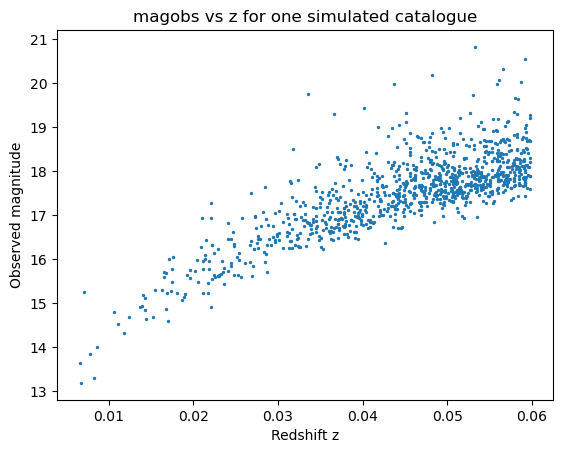

Number of SNe after selection: 1000


In [10]:
# Take one simulation
example = results[6]

# Convert columns to NumPy arrays for easier indexing
magobs = np.array(example['magobs'])
z      = np.array(example['z'])

# Apply selection (magobs > 0)
mask = magobs > 0
magobs_cut = magobs[mask]
z_cut = z[mask]

# Plot
plt.figure()
plt.scatter(z_cut, magobs_cut, s=2)
plt.xlabel("Redshift z")
plt.ylabel("Observed magnitude")
plt.title("magobs vs z for one simulated catalogue")
plt.show()

# Number of SNe after selection
print('Number of SNe after selection:', len(magobs_cut))


In [11]:
# Jax libraries
import jax
import jax.numpy as jnp

In [12]:
# Try GPU backends in priority order
gpu = None
for backend in ("METAL", "cuda", "gpu"):
    try:
        devs = jax.devices(backend)
    except RuntimeError:
        continue
    if devs:
        gpu = devs[0]
        break

# Fallback
cpu = jax.devices("cpu")[0]

# Use GPU if found
if gpu=='cuda':
    nntr.print_gpu_memory()
    device = gpu 
elif gpu is not None:
    device = gpu
else:
    device = cpu
    
jax.default_device(device)
    
backend = jax.default_backend()
print(backend)

gpu


In [13]:
key = jax.random.PRNGKey(42)

## Pre-process samples

In [14]:
filtered_results = []
sizes = []

for sim_data in results:
    quality_mask = get_quality_mask(sim_data)

    filtered_data = {
        key: np.asarray(value)[quality_mask]
        for key, value in sim_data.items()
    }

    filtered_results.append(filtered_data)
    sizes.append(len(filtered_data["magobs"]))

max_size = max(sizes)

data_dict = {
    col: np.zeros((N_total, max_size), dtype=np.float32)
    for col in columns
}

for i, sim_data in enumerate(filtered_results):
    for col, arr in sim_data.items():
        arr = np.asarray(arr, dtype=np.float32)
        data_dict[col][i, : arr.shape[0]] = arr

In [15]:
z = data_dict['z']
magobs = data_dict["magobs"]      # (N,M)
mask = magobs != 0           # (N,M)

In [16]:
# Take care to not run the correction twice
mu_planck18, magobs_corr = nntr.rm_cosmo(z, magobs)
jax.config.update("jax_enable_x64", False)

data_dict['magobs'] = magobs_corr

The compilation cache as grown to 2.12 GB.Caching is disabled for now.Clear the cache using `cosmologix clear-cache -j` to re-enable.


In [17]:
# Make a copy to avoid in-place modification
columns = models_config['shared']['columns']
data_norm = {k: data_dict[k].copy() for k in columns}

data_stats = models_config['shared']['data_stats']

for col, arr in data_norm.items():
    mu = data_stats[col]['mu']
    sigma = data_stats[col]['sigma']

    if col == 'magobs':
        # mask zeros
        mag_mask = arr != 0.0
        data_norm[col] = arr.at[mag_mask].set((arr[mag_mask] - mu) / sigma)
    else:
        data_norm[col] = (arr - mu) / sigma

In [18]:
for model_g in models_per_group:
    model_g.eval()  # disable dropout, etc.

global_param_names = models_config['shared']['global_param_names']
print(f"Parameters : {global_param_names}")

param_groups = models_config['shared']['param_groups']

Parameters : ['mabs', 'beta', 'alpha', 'gamma']


In [19]:
priors = models_config['shared']['priors']

# Change the priors here if needed

# Example
# priors['alpha_low']['range'] = jnp.array([-0.4, -0.1])
# priors['alpha_high']['range'] = jnp.array([-0.2, 0.0])
# priors['gamma']['range'] = jnp.array([0.05, 0.2])
# priors['Om0']['range'] = jnp.array([0.2, 0.4])
# priors['sigma_int']['range'] = jnp.array([0.1, 0.2])
# Only update 'mabs' if it exists in params
if 'mabs' in default_params:
    default_params['mabs'] = default_params['mabs'] + 19.3

In [20]:
param_stats = models_config['shared']['param_stats']

normalized_priors = {}

for name, prior in priors.items():
    mu = param_stats[name]['mu']
    sigma = param_stats[name]['sigma']

    norm_range = (prior['range'] - mu) / sigma
        
    normalized_priors[name] = {
        'range': norm_range,
        'type': prior['type']  # type stays unchanged
    }

theta_dict = {
    name: default_params[name]
    for name in global_param_names
}

theta_normed_dict = {
    name: (
        theta_dict[name] - param_stats[name]["mu"]
    ) / param_stats[name]["sigma"]
    for name in global_param_names
}

theta_normed = jnp.array(
    [theta_normed_dict[name] for name in global_param_names]
)

In [21]:
# Convert each column to a 1D array and concatenate into shape (M*C,)
# Prepare inference arrays
data_arrays = [data_norm[col] for col in columns]  # list of (M,)
n_cols = len(columns)

# Stack along last axis to get shape (M, n_cols)
data_stacked = jnp.stack(jnp.asarray(data_arrays), axis=-1)  

# Flatten and add batch dimension: (1, M * n_cols)
data_concat_infer = data_stacked.reshape(N_total, max_size * n_cols)

# Concatenate features + mask
inputs_infer = jnp.concatenate([data_concat_infer, jnp.asarray(mask).reshape(N_total,max_size)], axis=-1)

print(inputs_infer.shape)

(200, 9000)


In [22]:
# priors

In [23]:
theta_normed

Array([5.7962052e-06, 2.1650616e-02, 1.7320469e-01, 0.0000000e+00],      dtype=float32)

## Make inference

In [24]:
def sample_reference_point(rng_key, priors, param_names):
    """
    Sample a reference point uniformly over parameter ranges,
    consistent with the new prior structure.
    """
    rng_key, subkey = jax.random.split(rng_key)

    param_names = list(param_names)

    lows = jnp.array([priors[name]["range"][0] for name in param_names])
    highs = jnp.array([priors[name]["range"][1] for name in param_names])

    u = jax.random.uniform(subkey, shape=(len(param_names),))
    theta = lows + u * (highs - lows)

    return rng_key, theta

def one_sample_step_groups(
    rng_key,
    xi,
    theta_star,
    priors,
    param_names,
    models_per_group,
    visible_indices,
    group_indices,
    group_names_list,
    param_stats,
    data_stats,
    n_warmup,
    n_samples,
):
    rng_key, key_r0, key_mcmc = jax.random.split(rng_key, 3)

    _, theta_r0 = sample_reference_point(key_r0, priors, param_names)

    def log_post(theta):
        return nninf.log_prob_fn_groups(
            theta,
            models_per_group,
            xi,
            priors,
            visible_indices,
            group_indices,
            group_names_list,
        )

    rng_key, posterior = nninf.sample_posterior(
        log_post, n_warmup, n_samples, theta_star, key_mcmc
    )

    mus = jnp.array([param_stats[name]["mu"] for name in param_names])
    sigmas = jnp.array([param_stats[name]["sigma"] for name in param_names])
    
    posterior_unnormed = posterior * sigmas + mus
    theta_star_unnormed = theta_star * sigmas + mus
    theta_r0_unnormed = theta_r0 * sigmas + mus

    d_star = jnp.linalg.norm(theta_star_unnormed - theta_r0_unnormed)
    d_samples = jnp.linalg.norm(posterior_unnormed - theta_r0_unnormed, axis=1)

    f_val = jnp.mean(d_samples < d_star)

    return f_val, posterior_unnormed


def compute_ecp_tarp_groups(
    models_per_group,
    x_list,
    theta_star_list,
    alpha_list,
    priors,
    param_names,
    visible_indices,
    group_indices,
    group_names_list,
    param_stats,
    data_stats,
    n_warmup,
    n_samples,
    rng_key,
):
    def scan_step(rng_key, xi_theta):
        xi, theta_star = xi_theta
        rng_key, subkey = jax.random.split(rng_key)

        f_val, posterior = one_sample_step_groups(
            subkey,
            xi,
            theta_star,
            priors,
            param_names,
            models_per_group,
            visible_indices,
            group_indices,
            group_names_list,
            param_stats,
            data_stats,
            n_warmup,
            n_samples,
        )

        return rng_key, (f_val, posterior)
    
    rng_key, (f_vals, posteriors) = jax.lax.scan(
        scan_step, rng_key, (x_list, theta_star_list)
    )

    ecp_vals = [jnp.mean(f_vals < (1.0 - alpha)) for alpha in alpha_list]

    return ecp_vals, f_vals, posteriors, rng_key

In [25]:
# ========== MCMC Sampling ==========

# ----------------------------
# Precompute parameter indices
# ----------------------------

alpha_grid = jnp.linspace(0, 1, 50)

theta_star_list = jnp.repeat(
    theta_normed[None, :],
    inputs_infer.shape[0],
    axis=0
)

group_names_list = []
for g in param_groups:
    if isinstance(g, str):
        group_names_list.append([g])  # wrap single parameter in a list
    else:
        group_names_list.append(g)  
        
visible_indices, group_indices = nninf.preprocess_groups(param_groups, global_param_names)

In [26]:
print("Launching TARP computation (this may take time) ...")

with jax.default_device(cpu):
    ecp_vals, f_vals, posteriors, key = compute_ecp_tarp_groups(
        models_per_group=models_per_group,
        x_list=inputs_infer,
        theta_star_list=theta_star_list,
        alpha_list=alpha_grid,
        priors=normalized_priors,
        param_names=global_param_names,
        visible_indices=visible_indices,
        group_indices=group_indices,
        group_names_list=group_names_list,
        param_stats = models_config['shared']['param_stats'],
        data_stats = models_config['shared']['data_stats'],
        n_warmup=100,
        n_samples=200,
        rng_key=key,
    )

print("... MCMC finished")


Launching TARP computation (this may take time) ...
... MCMC finished


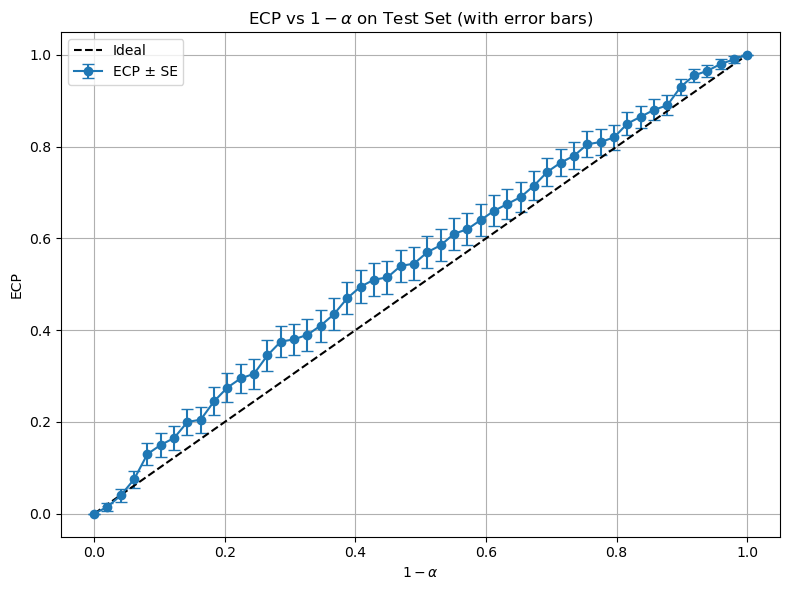

In [27]:
# Example: 1 - alpha grid and computed ecp
alpha_grid = jnp.array(alpha_grid)

ecp = jnp.array(ecp_vals)
se = jnp.sqrt(ecp * (1 - ecp) / len(f_vals)) #https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval#Wald_interval

# CHECK HOW TO COMPUTE THE ERROR

# Plot with error bars
plt.figure(figsize=(8, 6))
plt.errorbar(1 - alpha_grid, ecp, yerr=se, fmt='o-', capsize=4, label='ECP ± SE')
plt.plot([0, 1], [0, 1], 'k--', label='Ideal')
plt.xlabel(r'$1 - \alpha$')
plt.ylabel("ECP")
plt.title("ECP vs $1 - \\alpha$ on Test Set (with error bars)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()